# DQN Experiments

This notebook runs the Phase 1 Deep Q-Network baseline for the static maze environment.

It follows the same flow as the Q-learning notebook:

- environment inspection
- DQN training
- greedy evaluation
- metrics summary
- model saving
- learning, success, Q-value, and policy visualizations

DQN uses the full flat maze observation as neural-network input instead of a tabular state index.

## 1. Notebook Setup

Run this first so imports work whether the notebook is opened from the project root or from the `notebooks/` folder.

In [33]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

PosixPath('/home/hiba/Desktop/Maze-and-Path-Finding-main 1/Maze-and-Path-Finding-main')

In [34]:
%pip install matplotlib seaborn scikit-learn pandas numpy torch

Note: you may need to restart the kernel to use updated packages.


In [35]:
import json
import numpy as np

from src.agents import DQNAgent
from src.env import LEVEL_SIZES, MazeEnv, ACTION_NAMES
from src.training.evaluator import evaluate_dqn
from src.training.trainer_dqn import train_dqn, rollout_greedy_path, q_table_from_dqn
from src.utils.io import DIRS, ensure_dirs, figure_path, save_dqn, save_metrics
from src.utils.seed import set_global_seed
from src.visualization.heatmaps import plot_q_heatmap
from src.visualization.plots import plot_learning_curve, plot_success_curve
from src.visualization.policy_maps import plot_policy_arrows

ensure_dirs()
print("Imports ready")

Imports ready


## 2. Experiment Configuration

For a fast test, set `EPISODES = 10` or `50`. For a more meaningful DQN baseline, use `EPISODES = 1000` or more. Start with `small`; `large` is much slower for DQN.

In [36]:
LEVEL = "small"  # tiny=8, small=10, medium=20, large=50
SIZE = LEVEL_SIZES[LEVEL]
DIFFICULTY = "hard"  # easy, medium, hard
SEED = 42
EPISODES = 500
LOG_EVERY = 50

LEARNING_RATE = 1e-3
GAMMA = 0.99
EPSILON_START = 1.0
EPSILON_END = 0.05
EPSILON_DECAY = 0.995
BUFFER_SIZE = 50_000
BATCH_SIZE = 64
TARGET_UPDATE_EVERY = 250
WARMUP_STEPS = 500
HIDDEN_DIMS = (128, 128)
DEVICE = "cpu"

RUN_ID = f"dqn_{LEVEL}_{DIFFICULTY}_seed{SEED}"
RUN_ID

'dqn_small_hard_seed42'

## 3. Create and Inspect the Maze Environment

In [37]:
set_global_seed(SEED)

env = MazeEnv(level=LEVEL, difficulty=DIFFICULTY, seed=SEED)
env.action_space.seed(SEED)

obs, info = env.reset()

print("Level:", env.level)
print("Difficulty:", env.difficulty)
print("Maze size:", env.size)
print("Observation shape:", obs.shape)
print("Action space:", env.action_space.n)
print("Start:", env.start_pos)
print("Goal:", env.goal_pos)
print("Max steps:", env.max_steps)
print("Optimal path length:", info["optimal_path_len"])
print("Actions:", ACTION_NAMES)

Level: small
Difficulty: hard
Maze size: 10
Observation shape: (100,)
Action space: 4
Start: (0, 0)
Goal: (9, 9)
Max steps: 400
Optimal path length: 28
Actions: {0: 'Up', 1: 'Down', 2: 'Left', 3: 'Right'}


In [38]:
env.maze

array([[0, 0, 1, 1, 0, 1, 0, 0, 0, 0],
       [0, 0, 1, 1, 0, 0, 0, 0, 0, 0],
       [0, 1, 1, 1, 0, 0, 0, 1, 1, 0],
       [0, 0, 0, 1, 0, 0, 0, 1, 1, 0],
       [0, 0, 0, 1, 0, 0, 1, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 1, 0, 1],
       [1, 0, 0, 0, 0, 1, 1, 1, 0, 0],
       [0, 1, 1, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]], dtype=int32)

Optional maze display. If matplotlib has a NumPy compatibility problem in your environment, skip this cell.

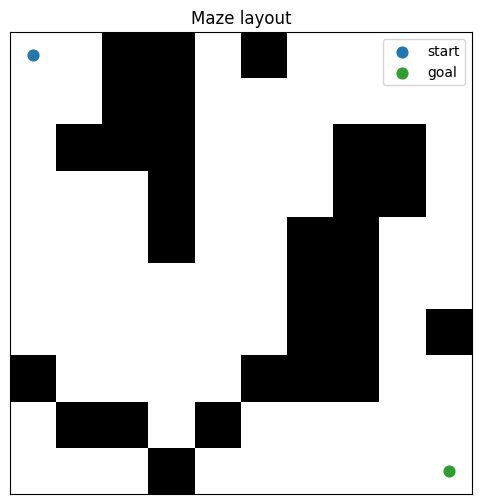

In [39]:
try:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(6, 6))
    plt.imshow(env.maze, cmap="binary")
    plt.scatter([env.start_pos[1]], [env.start_pos[0]], c="tab:blue", s=60, label="start")
    plt.scatter([env.goal_pos[1]], [env.goal_pos[0]], c="tab:green", s=60, label="goal")
    plt.xticks([])
    plt.yticks([])
    plt.legend()
    plt.title("Maze layout")
    plt.show()
except Exception as exc:
    print("Plot skipped:", exc)

## 4. Initialize DQN Agent

In [40]:
agent = DQNAgent(
    obs_dim=env.observation_space.shape[0],
    n_actions=env.action_space.n,
    learning_rate=LEARNING_RATE,
    gamma=GAMMA,
    epsilon_start=EPSILON_START,
    epsilon_end=EPSILON_END,
    epsilon_decay=EPSILON_DECAY,
    buffer_size=BUFFER_SIZE,
    batch_size=BATCH_SIZE,
    target_update_every=TARGET_UPDATE_EVERY,
    warmup_steps=WARMUP_STEPS,
    hidden_dims=HIDDEN_DIMS,
    seed=SEED,
    device=DEVICE,
)


agent

## 5. Train DQN

In [41]:
result = train_dqn(
    env=env,
    agent=agent,
    episodes=EPISODES,
    log_every=LOG_EVERY,
)

summary = result.tracker.compute_summary()
summary

Episode    50/500 | return=-47.610 | steps= 400 | success=0 | eps=0.782 | loss=0.0003 | rolling_success=n/a
Episode   100/500 | return=-35.850 | steps= 400 | success=0 | eps=0.609 | loss=0.0005 | rolling_success=10.00%
Episode   150/500 | return= -8.950 | steps= 163 | success=1 | eps=0.474 | loss=0.0012 | rolling_success=36.00%
Episode   200/500 | return= -9.730 | steps= 143 | success=1 | eps=0.369 | loss=0.0005 | rolling_success=64.00%
Episode   250/500 | return= -3.530 | steps=  62 | success=1 | eps=0.287 | loss=0.0006 | rolling_success=82.00%
Episode   300/500 | return= -6.450 | steps= 158 | success=1 | eps=0.223 | loss=0.0005 | rolling_success=99.00%
Episode   350/500 | return= -0.770 | steps=  80 | success=1 | eps=0.174 | loss=0.0003 | rolling_success=95.00%
Episode   400/500 | return=  0.550 | steps=  46 | success=1 | eps=0.135 | loss=0.0005 | rolling_success=95.00%
Episode   450/500 | return= -0.330 | steps=  36 | success=1 | eps=0.105 | loss=0.0004 | rolling_success=100.00%
Epi

{'success_rate': 1.0,
 'mean_return': 0.0286,
 'std_return': 0.7374,
 'mean_steps_to_goal': 41.3,
 'std_steps_to_goal': 16.42,
 'convergence_episode': 278,
 'sample_efficiency': 74942.0,
 'path_optimality': 0.678,
 'optimal_path_len': 28,
 'total_episodes': 500}

## 6. Greedy Evaluation

In [51]:
eval_result = evaluate_dqn(env, agent, episodes=100)

eval_summary = {
    "eval_success_rate": round(eval_result.success_rate, 4),
    "eval_mean_return": round(eval_result.mean_return, 4),
    "eval_mean_steps": round(eval_result.mean_steps, 2),
}

eval_summary

{'eval_success_rate': 1.0, 'eval_mean_return': 0.73, 'eval_mean_steps': 28.0}

## 7. Save Model and Metrics

In [52]:
summary.update(
    {
        **eval_summary,
        "maze_size": env.size,
        "level": env.level,
        "difficulty": env.difficulty,
        "max_steps": env.max_steps,
        "loss_count": len(result.losses),
    }
)

model_path = save_dqn(agent.q_network, RUN_ID)
metrics_path = save_metrics(
    {
        "episodes": result.tracker.episodes_arr,
        "rewards": result.tracker.rewards,
        "steps": result.tracker.steps_arr,
        "success": result.tracker.success_arr,
        "losses": np.asarray(result.losses, dtype=float),
    },
    RUN_ID,
)

paths_json = DIRS["metrics"] / f"{RUN_ID}_paths.json"
paths_json.write_text(
    json.dumps({name: [[int(r), int(c)] for r, c in path] for name, path in result.paths.items()}, indent=2),
    encoding="utf-8",
)

summary_path = DIRS["logs"] / f"{RUN_ID}_notebook_summary.json"
summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")

model_path, metrics_path, paths_json, summary_path

  [io] DQN model saved -> /home/hiba/Desktop/Maze-and-Path-Finding-main 1/Maze-and-Path-Finding-main/models/dqn/dqn_small_hard_seed42.pt
  [io] metrics saved -> /home/hiba/Desktop/Maze-and-Path-Finding-main 1/Maze-and-Path-Finding-main/results/metrics/dqn_small_hard_seed42_metrics.npz


(PosixPath('/home/hiba/Desktop/Maze-and-Path-Finding-main 1/Maze-and-Path-Finding-main/models/dqn/dqn_small_hard_seed42.pt'),
 PosixPath('/home/hiba/Desktop/Maze-and-Path-Finding-main 1/Maze-and-Path-Finding-main/results/metrics/dqn_small_hard_seed42_metrics.npz'),
 PosixPath('/home/hiba/Desktop/Maze-and-Path-Finding-main 1/Maze-and-Path-Finding-main/results/metrics/dqn_small_hard_seed42_paths.json'),
 PosixPath('/home/hiba/Desktop/Maze-and-Path-Finding-main 1/Maze-and-Path-Finding-main/results/logs/dqn_small_hard_seed42_notebook_summary.json'))

## 8. Learning Curves

/tmp/ipykernel_149994/2468425298.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_149994/2468425298.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


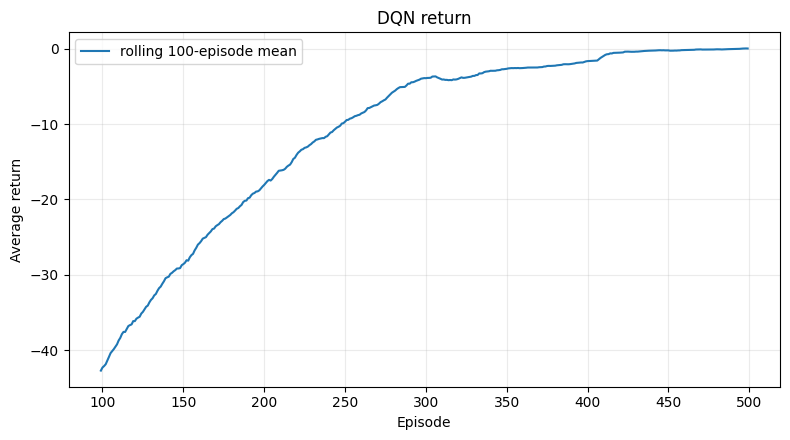

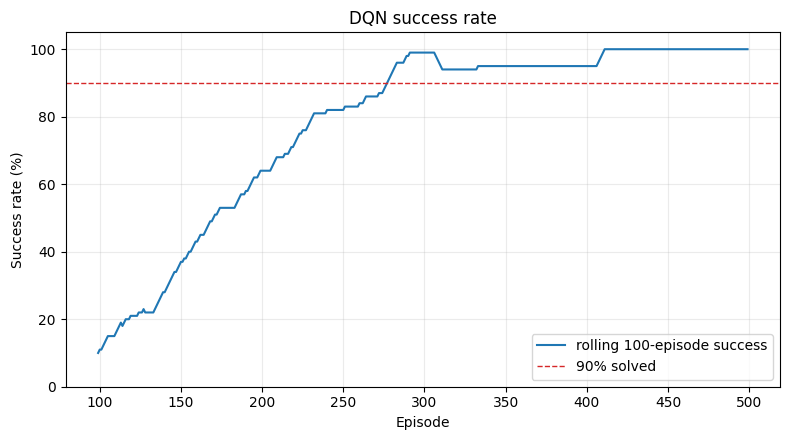

In [53]:
try:
    fig = plot_learning_curve(result.tracker.rewards, title="DQN return")
    fig.savefig(figure_path(RUN_ID + "_notebook", "learning_curve"), dpi=150)
    fig.show()

    fig = plot_success_curve(result.tracker.success_arr, title="DQN success rate")
    fig.savefig(figure_path(RUN_ID + "_notebook", "success_curve"), dpi=150)
    fig.show()
except Exception as exc:
    print("Plot skipped:", exc)

## 9. Q-Value Heatmap and Greedy Policy

The network is evaluated once for every possible agent cell to produce a Q-table-like array for the existing visualization helpers.

In [54]:
q_values_by_cell = q_table_from_dqn(env, agent)
q_values_by_cell.shape

(100, 4)

/tmp/ipykernel_149994/1429577060.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_149994/1429577060.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


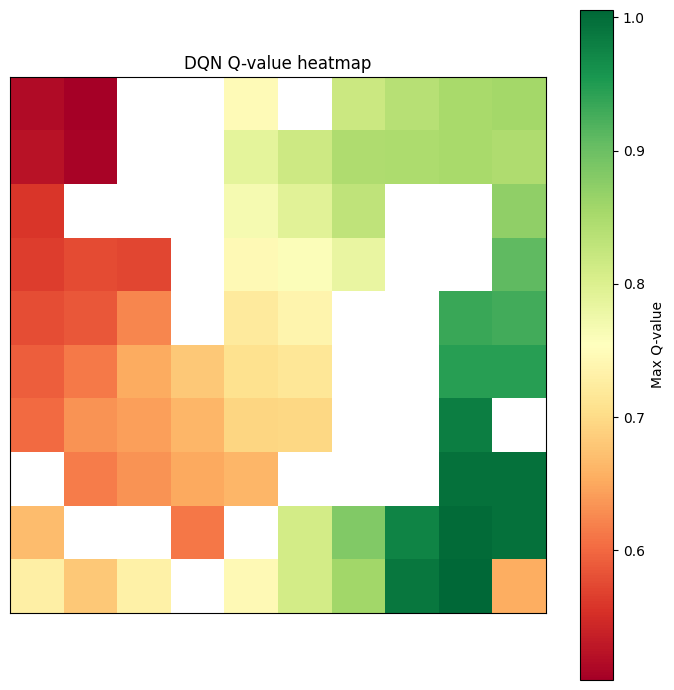

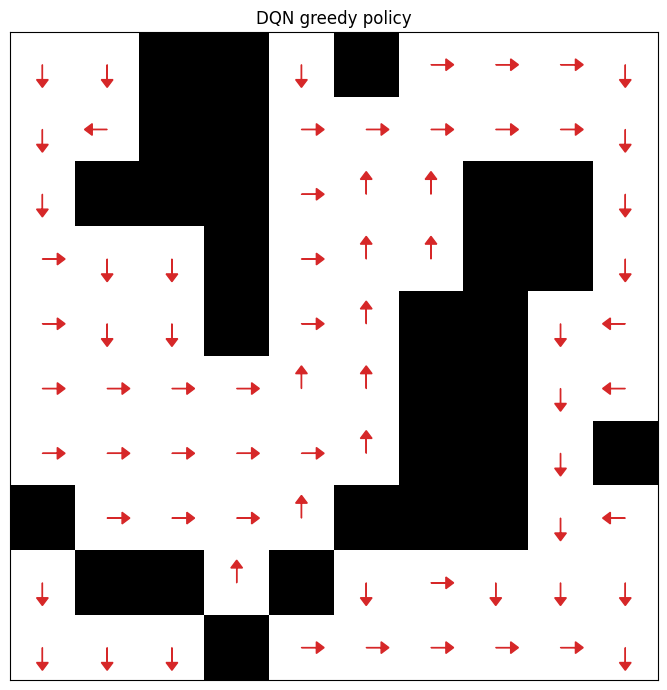

In [55]:
try:
    fig = plot_q_heatmap(q_values_by_cell, env.maze, title="DQN Q-value heatmap")
    fig.savefig(figure_path(RUN_ID + "_notebook", "q_heatmap"), dpi=150)
    fig.show()

    fig = plot_policy_arrows(q_values_by_cell, env.maze, title="DQN greedy policy")
    fig.savefig(figure_path(RUN_ID + "_notebook", "policy_map"), dpi=150)
    fig.show()
except Exception as exc:
    print("Plot skipped:", exc)

## 10. Greedy Path After Training

In [56]:
greedy_path = rollout_greedy_path(env, agent)
len(greedy_path), greedy_path[:10], greedy_path[-10:]

(29,
 [(0, 0),
  (1, 0),
  (2, 0),
  (3, 0),
  (3, 1),
  (4, 1),
  (5, 1),
  (5, 2),
  (5, 3),
  (5, 4)],
 [(2, 9),
  (3, 9),
  (4, 9),
  (4, 8),
  (5, 8),
  (6, 8),
  (7, 8),
  (8, 8),
  (9, 8),
  (9, 9)])

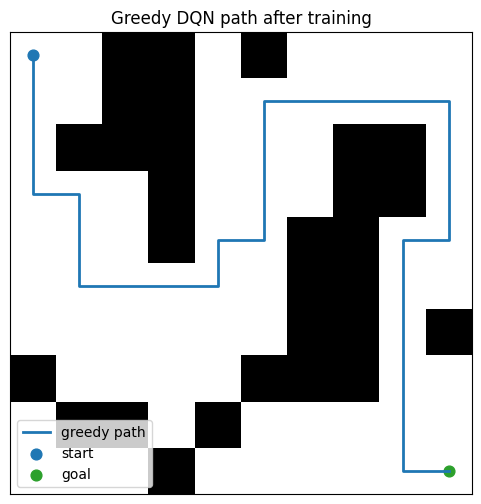

In [57]:
try:
    import matplotlib.pyplot as plt

    ys = [r for r, c in greedy_path]
    xs = [c for r, c in greedy_path]

    plt.figure(figsize=(6, 6))
    plt.imshow(env.maze, cmap="binary")
    plt.plot(xs, ys, color="tab:blue", linewidth=2, label="greedy path")
    plt.scatter([env.start_pos[1]], [env.start_pos[0]], c="tab:blue", s=60, label="start")
    plt.scatter([env.goal_pos[1]], [env.goal_pos[0]], c="tab:green", s=60, label="goal")
    plt.xticks([])
    plt.yticks([])
    plt.legend()
    plt.title("Greedy DQN path after training")
    plt.show()
except Exception as exc:
    print("Plot skipped:", exc)

## 11. Compare Multiple Seeds

Use this optional cell to run the same DQN experiment over several seeds. This is slower than tabular Q-learning, so keep the episode count modest until the setup is stable.

In [49]:
RUN_MULTI_SEED = False
multi_seed_episodes = 1000
seeds = [1, 2, 3, 4, 5]

multi_seed_results = []

if RUN_MULTI_SEED:
    for seed in seeds:
        set_global_seed(seed)
        seed_env = MazeEnv(level=LEVEL, difficulty=DIFFICULTY, seed=seed)
        seed_env.action_space.seed(seed)
        seed_agent = DQNAgent(
            obs_dim=seed_env.observation_space.shape[0],
            n_actions=seed_env.action_space.n,
            learning_rate=LEARNING_RATE,
            gamma=GAMMA,
            epsilon_start=EPSILON_START,
            epsilon_end=EPSILON_END,
            epsilon_decay=EPSILON_DECAY,
            buffer_size=BUFFER_SIZE,
            batch_size=BATCH_SIZE,
            target_update_every=TARGET_UPDATE_EVERY,
            warmup_steps=WARMUP_STEPS,
            hidden_dims=HIDDEN_DIMS,
            seed=seed,
            device=DEVICE,
        )
        seed_result = train_dqn(seed_env, seed_agent, episodes=multi_seed_episodes, log_every=0)
        seed_eval = evaluate_dqn(seed_env, seed_agent, episodes=100)
        seed_summary = seed_result.tracker.compute_summary()
        seed_summary.update(
            {
                "seed": seed,
                "eval_success_rate": seed_eval.success_rate,
                "eval_mean_return": seed_eval.mean_return,
                "eval_mean_steps": seed_eval.mean_steps,
            }
        )
        multi_seed_results.append(seed_summary)

multi_seed_results

[]

## 12. Multi-seed Summary

Run this after the previous cell if `RUN_MULTI_SEED = True`.

In [50]:
if multi_seed_results:
    success_rates = np.array([r["eval_success_rate"] for r in multi_seed_results], dtype=float)
    returns = np.array([r["eval_mean_return"] for r in multi_seed_results], dtype=float)
    steps = np.array([r["eval_mean_steps"] for r in multi_seed_results], dtype=float)

    aggregate = {
        "success_rate_mean": float(np.mean(success_rates)),
        "success_rate_std": float(np.std(success_rates)),
        "return_mean": float(np.mean(returns)),
        "return_std": float(np.std(returns)),
        "steps_mean": float(np.mean(steps)),
        "steps_std": float(np.std(steps)),
    }
else:
    aggregate = "Set RUN_MULTI_SEED = True and run the previous cell first."

aggregate

'Set RUN_MULTI_SEED = True and run the previous cell first.'